# Introducción a la clasificación binaria
¡Bienvenido! Este cuaderno te guiará a través de los conceptos básicos de la clasificación binaria utilizando la base de datos de diabetes de los indios Pima. Cargaremos los datos, los exploraremos brevemente, construiremos un modelo de clasificación sencillo (regresión logística) y evaluaremos su rendimiento.

## Funcionamiento de la Regresión Logística

La regresión logística sigue una serie de pasos para predecir la probabilidad de que una observación pertenezca a una determinada clase.

### 1. Se recopilan los valores de las variables independientes

Estas variables representan las características que se utilizarán para realizar la predicción.

### 2. Se calcula la combinación lineal

La combinación lineal se obtiene mediante la siguiente ecuación:

$$
z=\beta_0+\beta_1x_1+\beta_2x_2+\cdots+\beta_nx_n
$$

donde:

- $\beta_0$ = Intercepto del modelo.
- $\beta_1,\beta_2,\ldots,\beta_n$ = Coeficientes de las variables independientes.
- $x_1,x_2,\ldots,x_n$ = Variables independientes.

### 3. Se aplica la función sigmoide

El valor obtenido de $z$ se transforma en una probabilidad mediante la función sigmoide:

$$
P(y=1)=\frac{1}{1+e^{-z}}
$$

Esta función convierte cualquier valor de $z$ en una probabilidad comprendida entre 0 y 1.

### 4. Se obtiene una probabilidad

El resultado representa la probabilidad de que la observación pertenezca a la clase positiva.

- Si la probabilidad es cercana a **1**, existe una alta probabilidad de pertenecer a la clase positiva.
- Si la probabilidad es cercana a **0**, existe una baja probabilidad de pertenecer a la clase positiva.

### 5. Se compara con un umbral de decisión

Generalmente se utiliza un umbral de **0.5** para realizar la clasificación:

- Si $P(y=1)\geq0.5$, la observación se clasifica como **Clase 1**.
- Si $P(y=1)<0.5$, la observación se clasifica como **Clase 0**.


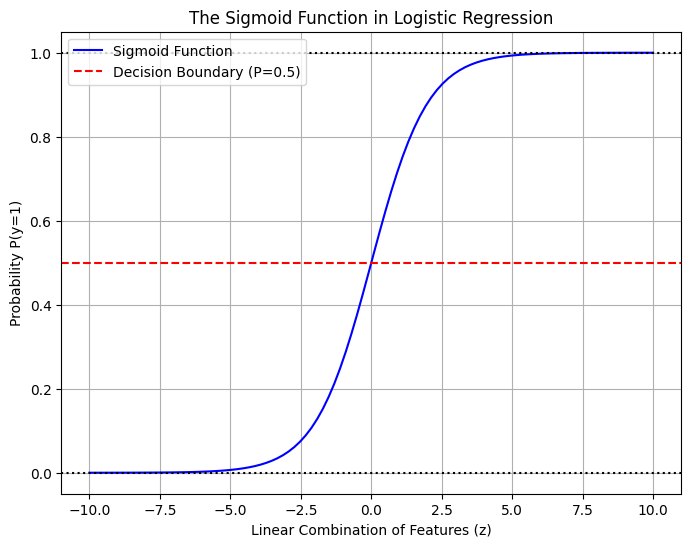

In [ ]:
#@title The Sigmoid Function
import numpy as np
import matplotlib.pyplot as plt

# Define the sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Generate values for z
z = np.linspace(-10, 10, 100)

# Calculate the sigmoid for each z
probability = sigmoid(z)

# Plot the sigmoid function
plt.figure(figsize=(8, 6))
plt.plot(z, probability, label='Sigmoid Function', color='blue')
plt.axhline(0.5, color='red', linestyle='--', label='Decision Boundary (P=0.5)')
plt.axhline(0, color='black', linestyle=':')
plt.axhline(1, color='black', linestyle=':')
plt.xlabel('Linear Combination of Features (z)')
plt.ylabel('Probability P(y=1)')
plt.title('The Sigmoid Function in Logistic Regression')
plt.grid(True)
plt.legend()
plt.show()

# Trabajo con un conjunto de datos del mundo real: Predicción de diabetes
La base de datos sobre diabetes de los indios Pima contiene mediciones de diagnóstico médico de pacientes pertenecientes a esta etnia, así como una variable de resultado binaria que indica si padecen diabetes o no. Nuestro objetivo es construir un modelo capaz de predecir si un paciente tiene diabetes a partir de dichas mediciones.

## Carga del conjunto de datos

En primer lugar, descargaremos el conjunto de datos de Kaggle y lo cargaremos en un DataFrame de pandas.

In [3]:
# ============================================================
# Importación de bibliotecas
# ============================================================

# Pandas: Se utiliza para cargar, manipular y analizar datos
# en estructuras tipo DataFrame.
import pandas as pd

# Matplotlib: Biblioteca para crear gráficos y visualizar datos.
import matplotlib.pyplot as plt

# Seaborn: Complementa a Matplotlib con gráficos estadísticos
# más atractivos y fáciles de interpretar.
import seaborn as sns

# train_test_split: Divide el conjunto de datos en dos partes:
# entrenamiento y prueba, para evaluar el rendimiento del modelo.
from sklearn.model_selection import train_test_split

# LogisticRegression: Implementa el algoritmo de regresión logística,
# utilizado para resolver problemas de clasificación binaria.
from sklearn.linear_model import LogisticRegression

# accuracy_score: Calcula la exactitud (Accuracy), es decir,
# el porcentaje de predicciones correctas del modelo.
#
# classification_report: Genera un informe con métricas de evaluación
# como Precisión (Precision), Sensibilidad (Recall), F1-score y Support.
#
# confusion_matrix: Construye la matriz de confusión para comparar
# las clases reales con las predichas por el modelo.
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
# Load the dataset
df_diabetes = pd.read_csv('diabetes.csv')

# Display the first few rows
print(df_diabetes.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [7]:
df_diabetes.shape

(768, 9)

## Visualización de la variable objetivo

Es importante observar la distribución de nuestra variable objetivo (diabetes frente a ausencia de diabetes).

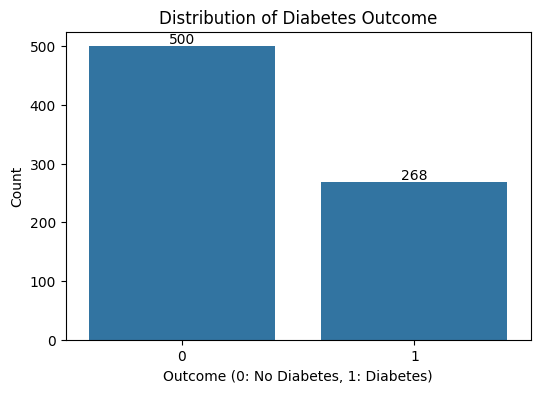

In [5]:
# Visualize the distribution of the target variable
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='Outcome', data=df_diabetes)
# Agregar la cantidad sobre cada barra
for container in ax.containers:
    ax.bar_label(container)
plt.title('Distribution of Diabetes Outcome')
plt.xlabel('Outcome (0: No Diabetes, 1: Diabetes)')
plt.ylabel('Count')
plt.show()

In [6]:
# ============================================================
# Preparación y entrenamiento del modelo de Regresión Logística
# ============================================================

# Definir las variables independientes (X) y la variable objetivo (y).

# X contiene todas las características del paciente que serán utilizadas
# para realizar la predicción.

# y corresponde a la variable objetivo (Outcome), donde:
# 0 = No tiene diabetes
# 1 = Tiene diabetes
X = df_diabetes.drop(columns=['Outcome'])
y = df_diabetes['Outcome']


# Dividir el conjunto de datos en entrenamiento y prueba.
#
# test_size=0.3 indica que:
# - 70% de los datos se utilizarán para entrenar el modelo.
# - 30% se utilizarán para evaluar su desempeño.
#
# random_state=42 fija una semilla para que la división sea siempre
# la misma y los resultados puedan reproducirse.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)


# Crear el modelo de Regresión Logística.
#
# solver='liblinear' especifica el algoritmo que utilizará
# Scikit-Learn para entrenar el modelo.
#
# Este solver es recomendado para conjuntos de datos pequeños
# y problemas de clasificación binaria.
#
# random_state=42 garantiza que el entrenamiento sea reproducible.
model_logistic = LogisticRegression(
    solver='liblinear',
    random_state=42
)


# Entrenar el modelo.
#
# Durante esta etapa el algoritmo aprende la relación entre
# las variables independientes (X_train) y la variable objetivo
# (y_train), calculando los coeficientes que mejor permiten
# clasificar a los pacientes.
model_logistic.fit(X_train, y_train)


# Realizar predicciones utilizando el conjunto de prueba.
#
# Una vez entrenado el modelo, se utilizan datos que el modelo
# nunca ha visto para predecir si cada paciente tiene diabetes
# (1) o no tiene diabetes (0).
y_pred_logistic = model_logistic.predict(X_test)

## Evaluación del Modelo

Ahora, evaluemos el rendimiento de nuestro modelo de **Regresión Logística** utilizando métricas comunes de clasificación.

- **Accuracy (Exactitud o Precisión global):**  
  Representa la proporción de instancias clasificadas correctamente respecto al total de instancias evaluadas.

- **Confusion Matrix (Matriz de Confusión):**  
  Es una tabla que muestra la cantidad de **verdaderos positivos (True Positives)**, **verdaderos negativos (True Negatives)**, **falsos positivos (False Positives)** y **falsos negativos (False Negatives)** obtenidos por el modelo.

- **Classification Report (Reporte de Clasificación):**  
  Proporciona métricas como **precisión (Precision)**, **sensibilidad (Recall)**, **puntaje F1 (F1-score)** y **soporte (Support)** para cada clase.

Accuracy: 0.75


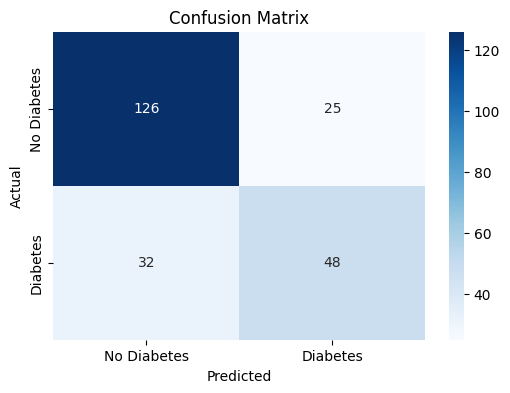


Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.83      0.82       151
           1       0.66      0.60      0.63        80

    accuracy                           0.75       231
   macro avg       0.73      0.72      0.72       231
weighted avg       0.75      0.75      0.75       231



In [8]:
# Evaluación del modelo mediante Accuracy
# Mide la proporción de predicciones correctas realizadas por el modelo.
accuracy = accuracy_score(y_test, y_pred_logistic)

print(f"Accuracy: {accuracy:.2f}")


# Generación de la matriz de confusión
# Permite visualizar los aciertos y errores del modelo:
# TN (Verdaderos negativos), TP (Verdaderos positivos),
# FP (Falsos positivos) y FN (Falsos negativos).
cm = confusion_matrix(y_test, y_pred_logistic)

plt.figure(figsize=(6, 4))

# Visualización gráfica de la matriz de confusión mediante un mapa de calor.
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Diabetes', 'Diabetes'],
    yticklabels=['No Diabetes', 'Diabetes']
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


# Reporte de clasificación
# Muestra las métricas Precision, Recall, F1-score y Support
# para cada una de las clases del modelo.
print("\nClassification Report:")
print(classification_report(y_test, y_pred_logistic))

## Interpretación de las Métricas de Evaluación

- **Accuracy (Exactitud):**  
  Nuestro modelo predijo correctamente el resultado de aproximadamente **{accuracy:.2f}** de los pacientes del conjunto de prueba.

- **Matriz de Confusión:**  
    - La celda superior izquierda muestra la cantidad de **verdaderos negativos (True Negatives)**, es decir, pacientes sin diabetes que fueron correctamente clasificados como no diabéticos.
    - La celda superior derecha muestra la cantidad de **falsos positivos (False Positives)**, es decir, pacientes sin diabetes que fueron incorrectamente clasificados como diabéticos.
    - La celda inferior izquierda muestra la cantidad de **falsos negativos (False Negatives)**, es decir, pacientes con diabetes que fueron incorrectamente clasificados como no diabéticos.
    - La celda inferior derecha muestra la cantidad de **verdaderos positivos (True Positives)**, es decir, pacientes con diabetes que fueron correctamente clasificados como diabéticos.

- **Reporte de Clasificación:**  
    - **Precision (Precisión):**  
      De todos los pacientes que el modelo predijo como diabéticos, ¿qué proporción realmente tenía diabetes?

    - **Recall (Sensibilidad):**  
      De todos los pacientes que realmente tenían diabetes, ¿qué proporción fue identificada correctamente por el modelo?

    - **F1-score:**  
      Representa la media armónica entre la precisión y la sensibilidad, proporcionando un equilibrio entre ambas métricas.

    - **Support (Soporte):**  
      Indica la cantidad de casos reales pertenecientes a cada clase dentro del conjunto de prueba.

## Realización de predicciones

Ahora podemos usar nuestro modelo entrenado para predecir el resultado en nuevos pacientes. Supongamos que tenemos un nuevo paciente con las siguientes mediciones:

In [10]:
# ============================================================
# PREDICCIÓN PARA UN NUEVO PACIENTE
# ============================================================

# Se crea un DataFrame con los datos de un nuevo paciente.
# Las variables deben tener el mismo formato y orden que los datos
# utilizados durante el entrenamiento del modelo.

new_patient = pd.DataFrame({
    'Pregnancies': [6],
    'Glucose': [148],
    'BloodPressure': [72],
    'SkinThickness': [35],
    'Insulin': [0],
    'BMI': [33.6],
    'DiabetesPedigreeFunction': [0.627],
    'Age': [50]
})


# Se utiliza el modelo de Regresión Logística entrenado para predecir
# la clase del nuevo paciente.
#
# Resultado:
# 0 → No Diabetes
# 1 → Diabetes

prediction = model_logistic.predict(new_patient)


# Se obtiene la probabilidad asociada a la clase positiva (clase 1).
# En este caso:
# Clase 0 → No Diabetes
# Clase 1 → Diabetes
#
# [:,1] selecciona únicamente la probabilidad de tener diabetes.

probability_diabetes = model_logistic.predict_proba(new_patient)[:, 1]


# Se muestra la predicción final del modelo junto con la probabilidad estimada. 
# Usualmente prediction devuelve un arreglo

if prediction[0] == 1:
    print(
        f"The model predicts that this patient has diabetes "
        f"(Probability: {probability_diabetes[0]:.2f})"
    )
else:
    print(
        f"The model predicts that this patient does not have diabetes "
        f"(Probability: {probability_diabetes[0]:.2f})"
    )

The model predicts that this patient has diabetes (Probability: 0.65)
